In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

I don't know why, but downloading the file directly using this notebook didn't work. I had to manually download and save it.

In [ ]:
data = "https://github.com/alexeygrigorev/mlbookcamp-code/blob/master/chapter-02-car-price/data.csv"
! wget $data

In [77]:
df = pd.read_csv("C:\\Users\\Gigabyte\\OneDrive\\Documentos\\QuantumControl\\Road_to_alternatives\\DataFiles\\data_cars_linregr.csv")

In [78]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [17]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='object')

In [19]:
df.shape

(11914, 16)

In [44]:
df.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

For data manipulation purposes, it is common to unify the format of column names and string variables. Tipically, we set all strings to lower case and spaces to underscores. Use the "apply()" function to operate over an entire data frame. If applying to just a column, or the column names themselves, apply the function directly to it.

In [3]:
df[df.columns[df.dtypes == 'object']] = df[df.columns[df.dtypes == 'object']].apply(lambda x: x.str.lower().str.replace(' ', '_'))
df.rename(columns=lambda x: x.lower().replace(' ', '_'), inplace=True)
#df.columns[df.dtypes == 'object'] = df.columns[df.dtypes == 'object'].str.lower().str.replace(' ', '_')


Now, visualize some data using histograms. Here we are particularly interested in the price of the cars.

In [2]:
import seaborn as sns

<Axes: xlabel='msrp', ylabel='Count'>

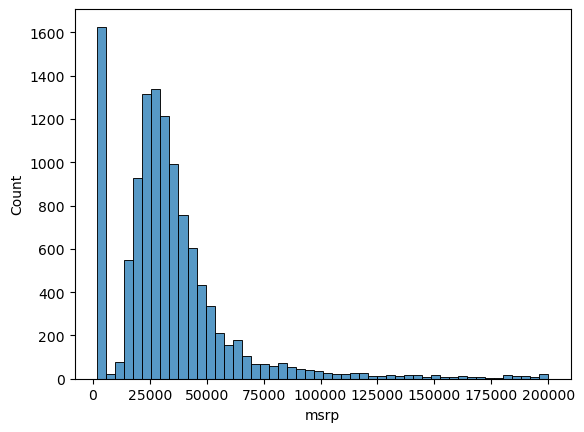

In [46]:
sns.histplot(data=df, x='msrp', bins=50, binrange=(df.msrp.min()-1, 2.e5))

Since there are orders of magnitude of difference in the prices of the cars, we better use logscale.

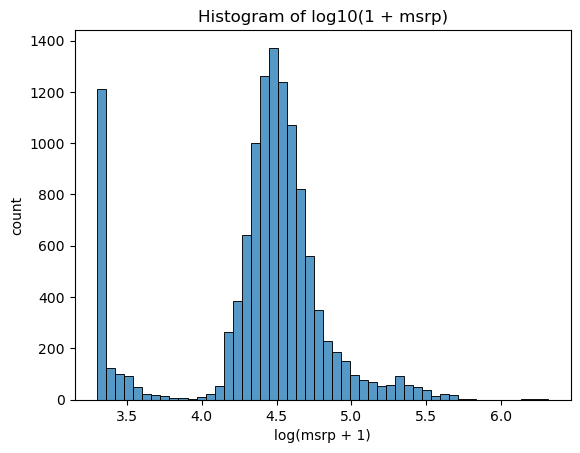

In [10]:
logprice = np.log10(1 + df.msrp)
ax = sns.histplot(logprice, bins=50 )
ax.set(xlabel='log(msrp + 1)', ylabel='count', title='Histogram of log10(1 + msrp)');

To predict the price of a car from its parameters (year, fuel efficiency, etc), we propose a multilinear model, i.e., we assume that the price depends linearly on all these variables. First, we have to isolate the numerical variables. Then, we need to prepare these data to feed a training algorithm (remove Nan's and outliers). Don't forget to split the data set into a training and a validation subsets.

In [55]:
df[df.columns[df.dtypes != 'object']].dtypes

year                  int64
engine_hp           float64
engine_cylinders    float64
number_of_doors     float64
highway_mpg           int64
city_mpg              int64
popularity            int64
msrp                  int64
dtype: object

In [70]:
numframe = df[df.columns[df.dtypes != 'object']]
numframe.isna().sum()

year                 0
engine_hp           69
engine_cylinders    30
number_of_doors      6
highway_mpg          0
city_mpg             0
popularity           0
msrp                 0
dtype: int64

Fill the NaN values with some numbers. Commom options are filling with zeros, and with the average of the remaining values.

In [71]:
numframe = numframe.fillna(numframe.mean()) 

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

Split the dataset and train the model. drop() eliminates one or more specific columns.

In [8]:
train, test = train_test_split(numframe, test_size=0.25)
LinearRegressionModel = LinearRegression().fit(train.drop(columns=['msrp']), train.msrp)

Validate with the test dataset. We use the R-squared score: $1-\sum_j(y_j^{pred} - y_j^{true})^2 / \sum_j(y_j^{pred} - \langle y_j^{pred} \rangle)^2$

In [9]:
LinearRegressionModel.score(test.drop(columns=['msrp']), test.msrp)

0.5340716484331548

Alternatively, you can simple use the root of the mean squared error.

In [22]:
root_mean_squared_error(LinearRegressionModel.predict(test.drop(columns=['msrp'])), test.msrp)

35060.985134022616

Visualize a histogram of the predicted values and compare with the actual values.

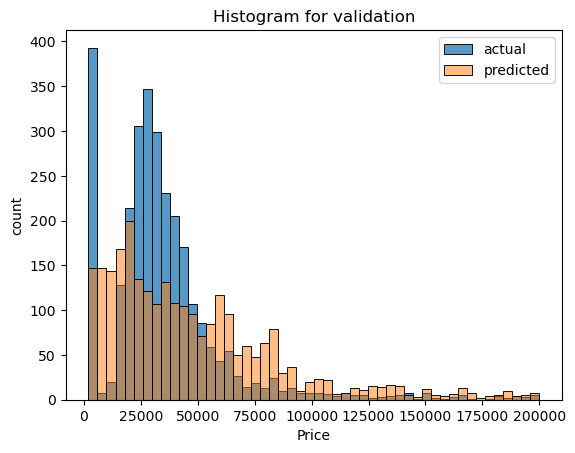

In [23]:
ax = sns.histplot(test["msrp"], bins=50, binrange=(df.msrp.min()-1, 2.e5), label='actual')
sns.histplot(LinearRegressionModel.predict(test.drop(columns=['msrp'])), bins=50, binrange=(df.msrp.min()-1, 2.e5), alpha=0.5, label='predicted')
ax.set(xlabel='Price', ylabel='count', title='Histogram for validation');
ax.legend();

As we can see, the price of the cars cannot be well described by a multi-linear model in terms of the involved parameters. We could now look at the categorical variables, for example, and use them to improve our model. Let's choose a categorical variable — the brand of the car, for example. We could add extra columns containing the names of the most frequent car brands and enter values of 0 or 1 to indicate whether or not the car is of that brand. This increases the number of variables in the model.

In [72]:
brands = df["make"].value_counts().head().index
extrafeatures = numframe.copy()

for v in brands:
  extrafeatures['make_%s' % v] = (df.make == v).astype('int')

In [73]:
train, test = train_test_split(extrafeatures, test_size=0.25)
LinearRegressionModel = LinearRegression().fit(train.drop(columns=['msrp']), train.msrp)

In [74]:
LinearRegressionModel.score(test.drop(columns=['msrp']), test.msrp)

0.5256647587090271

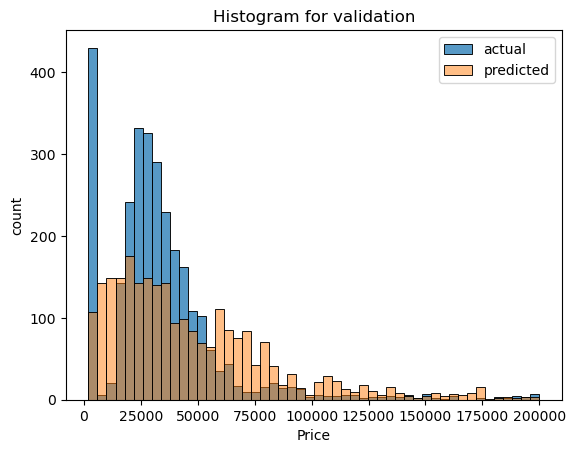

In [75]:
ax = sns.histplot(test["msrp"], bins=50, binrange=(df.msrp.min()-1, 2.e5), label='actual')
sns.histplot(LinearRegressionModel.predict(test.drop(columns=['msrp'])), bins=50, binrange=(df.msrp.min()-1, 2.e5), alpha=0.5, label='predicted')
ax.set(xlabel='Price', ylabel='count', title='Histogram for validation');
ax.legend();

In [41]:
LinearRegressionModel.score(test.drop(columns=['msrp']), test.msrp)

0.5087690961776125

Homework. It is a good moment to learn that pandas "read_csv" function can directly read a csv file stored in the cloud.

In [54]:
df = pd.read_csv("https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv")

In [82]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [83]:
df.shape

(9704, 11)

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

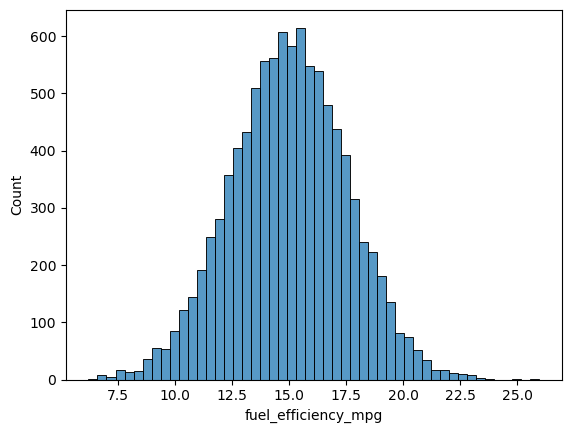

In [6]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

The distribution of the sample for the fuel efficiency seems to be normal, so it does not have a long tail.

In [7]:
df.isna().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

We'll use the 'engine_displacement', 'horsepower', 'vehicle_weight', and 'model_year' variables to train the model. As we can see, only 'horsepower' has missing values among these.

In [13]:
np.median(df.horsepower.dropna())

np.float64(149.0)

In [33]:
study_set = df[["engine_displacement", "horsepower", "vehicle_weight", "model_year", "fuel_efficiency_mpg"]]

def split_and_fill_missing(study_set:pd.DataFrame, fzero: bool, frac=[0.6, 0.2], random_state=42):
  train = study_set.sample(frac=frac[0], random_state=42)
  validation = study_set.drop(train.index).sample(frac=frac[1], random_state=random_state)
  test = study_set.drop(train.index).drop(validation.index)
  if fzero:
    train = train.fillna(0)
    validation = validation.fillna(0)
    test = test.fillna(0)
  else:
    avr = train.mean()
    train =  train.fillna(avr)
    validation = validation.fillna(avr)
    test = test.fillna(avr)

  return train, validation, test


In [36]:
train, validation, test = split_and_fill_missing(study_set, fzero=True)
LinRegZero = LinearRegression().fit(train.drop(columns=['fuel_efficiency_mpg']), train.fuel_efficiency_mpg)
print(root_mean_squared_error(LinRegZero.predict(validation.drop(columns=['fuel_efficiency_mpg'])), validation.fuel_efficiency_mpg))

0.529096982029614


In [55]:
train, validation, test = split_and_fill_missing(study_set, fzero=False)
LinRegAvr = LinearRegression().fit(train.drop(columns=['fuel_efficiency_mpg']), train.fuel_efficiency_mpg)
print(root_mean_squared_error(LinRegAvr.predict(validation.drop(columns=['fuel_efficiency_mpg'])), validation.fuel_efficiency_mpg))

0.4907177117823956


In [56]:
train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
483,220,144.0,2535.887591,2009,16.642943
7506,160,141.0,2741.170484,2019,16.298377
8795,230,155.0,2471.880237,2017,18.591822
1688,150,206.0,3748.164469,2015,11.818843
6217,300,111.0,2135.716359,2006,19.402209


In [ ]:
#This function resets the indices of the training DataFrame to ensure they are sequential and start from 0.
#This is useful for maintaining a clean dataset, especially after operations that may have altered the original indices, such as filtering or sampling.
train = train.reset_index(drop=True)
train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,220,144.0,2535.887591,2009,16.642943
1,160,141.0,2741.170484,2019,16.298377
2,230,155.0,2471.880237,2017,18.591822
3,150,206.0,3748.164469,2015,11.818843
4,300,111.0,2135.716359,2006,19.402209


In this case, filling Nan entries with the average performs better than filling with zeros. Now, use a regularized model. This simply consists of adding a constant value to the diagonal elements of the matrix we will compute the pseudo-inverse.

In [38]:
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [42]:
train, validation, test = split_and_fill_missing(study_set, fzero=True)
for r in [10.**i for i in range(-2, 3)]:
  b, a = train_linear_regression_reg(train.drop(columns=['fuel_efficiency_mpg']).values, train.fuel_efficiency_mpg.values, r=r)
  y_pred = b + validation.drop(columns=['fuel_efficiency_mpg']).values.dot(a)
  print(f"r={r}, RMSE={root_mean_squared_error(y_pred, validation.fuel_efficiency_mpg.values)}")

r=0.01, RMSE=0.5284428654901425
r=0.1, RMSE=0.5286245483906282
r=1.0, RMSE=0.5310127307489161
r=10.0, RMSE=0.5315755715238061
r=100.0, RMSE=0.531638276034192


As we can see, the option using regularization with r = 0.01 worked the best, giving the lowest RMSE among the tested values for the regularization parameter, including no regularization. Now, let's test how much the sampling affects the quality of the fitted model.

In [48]:
RMSEscores = []
for seed in range(10):
  train, validation, test = split_and_fill_missing(study_set, fzero=True, random_state=seed)
  LinRegZero = LinearRegression().fit(train.drop(columns=['fuel_efficiency_mpg']), train.fuel_efficiency_mpg)
  rmse = root_mean_squared_error(LinRegZero.predict(validation.drop(columns=['fuel_efficiency_mpg'])), validation.fuel_efficiency_mpg)
  RMSEscores.append(rmse)

np.std(RMSEscores)

np.float64(0.008782343016931838)

In [53]:
train, validation, test = split_and_fill_missing(study_set, fzero=True, random_state=9)
validation = pd.concat([validation, test], axis=0)
b, a = train_linear_regression_reg(train.drop(columns=['fuel_efficiency_mpg']).values, train.fuel_efficiency_mpg.values, r=0.001)
y_pred = b + validation.drop(columns=['fuel_efficiency_mpg']).values.dot(a)
print(root_mean_squared_error(y_pred, validation.fuel_efficiency_mpg.values))

0.5167875798113606
